In [ ]:
from google.colab import files
files.upload()
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
! kaggle competitions download -c facial-keypoints-detection

  0% 0.00/76.3M [00:00<?, ?B/s]
100% 76.3M/76.3M [00:00<00:00, 1.27GB/s]


In [ ]:
!unzip facial-keypoints-detection.zip

Archive:  facial-keypoints-detection.zip
  inflating: IdLookupTable.csv       
  inflating: SampleSubmission.csv    
  inflating: test.zip                
  inflating: training.zip            


In [ ]:
!unzip training.zip

Archive:  training.zip
  inflating: training.csv            


In [ ]:
import pandas as pd
import numpy as np
import os
import PIL
import seaborn as sns
import matplotlib.pyplot as plt
import copy
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras import *
from keras.initializers import glorot_uniform
from keras import backend as K
from keras import layers, optimizers
from keras.layers import *
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
import cv2
from keras.utils import to_categorical
from keras.src.legacy.preprocessing.image import ImageDataGenerator

In [ ]:
train = pd.read_csv('training.csv')
#test = pd.read_csv('test.csv')

In [ ]:
print(train.shape)
#print(test.shape)
print(train)
#print(test)

(7049, 31)
      left_eye_center_x  left_eye_center_y  right_eye_center_x  \
0             66.033564          39.002274           30.227008   
1             64.332936          34.970077           29.949277   
2             65.057053          34.909642           30.903789   
3             65.225739          37.261774           32.023096   
4             66.725301          39.621261           32.244810   
...                 ...                ...                 ...   
7044          67.402546          31.842551           29.746749   
7045          66.134400          38.365501           30.478626   
7046          66.690732          36.845221           31.666420   
7047          70.965082          39.853666           30.543285   
7048          66.938311          43.424510           31.096059   

      right_eye_center_y  left_eye_inner_corner_x  left_eye_inner_corner_y  \
0              36.421678                59.582075                39.647423   
1              33.448715                

In [ ]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7049 entries, 0 to 7048
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   left_eye_center_x          7039 non-null   float64
 1   left_eye_center_y          7039 non-null   float64
 2   right_eye_center_x         7036 non-null   float64
 3   right_eye_center_y         7036 non-null   float64
 4   left_eye_inner_corner_x    2271 non-null   float64
 5   left_eye_inner_corner_y    2271 non-null   float64
 6   left_eye_outer_corner_x    2267 non-null   float64
 7   left_eye_outer_corner_y    2267 non-null   float64
 8   right_eye_inner_corner_x   2268 non-null   float64
 9   right_eye_inner_corner_y   2268 non-null   float64
 10  right_eye_outer_corner_x   2268 non-null   float64
 11  right_eye_outer_corner_y   2268 non-null   float64
 12  left_eyebrow_inner_end_x   2270 non-null   float64
 13  left_eyebrow_inner_end_y   2270 non-null   float

In [ ]:
train.isnull().sum()

,0
left_eye_center_x,10
left_eye_center_y,10
right_eye_center_x,13
right_eye_center_y,13
left_eye_inner_corner_x,4778
left_eye_inner_corner_y,4778
left_eye_outer_corner_x,4782
left_eye_outer_corner_y,4782
right_eye_inner_corner_x,4781
right_eye_inner_corner_y,4781


In [ ]:
train.dropna(inplace=True)
#test.dropna(inplace=True)

In [ ]:
print(train.shape)
#print(test.shape)

(2140, 31)


In [ ]:
print(np.fromstring(train["Image"][0], dtype = int, sep = ' ').shape)

(9216,)


In [ ]:
train["Image"] = train["Image"].apply(lambda x: np.fromstring(x, dtype=int, sep=" ").reshape(96,96))
print(train["Image"][0].shape)

(96, 96)


In [ ]:
train.describe()

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_x,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y
count,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,...,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000
mean,66.221549,36.842274,29.640269,37.063815,59.272128,37.856014,73.412473,37.640110,36.603107,37.920852,...,47.952141,57.253926,63.419076,75.887660,32.967365,76.134065,48.081325,72.681125,48.149654,82.630412
std,2.087683,2.294027,2.051575,2.234334,2.005631,2.034500,2.701639,2.684162,1.822784,2.009505,...,3.276053,4.528635,3.650131,4.438565,3.595103,4.259514,2.723274,5.108675,3.032389,4.813557
min,47.835757,23.832996,18.922611,24.773072,41.779381,27.190098,52.947144,26.250023,24.112624,26.250023,...,24.472590,41.558400,43.869480,57.023258,9.778137,56.690208,32.260312,56.719043,33.047605,57.232296
25%,65.046300,35.468842,28.472224,35.818377,58.113054,36.607950,71.741978,36.102409,35.495730,36.766783,...,46.495330,54.466000,61.341291,72.874263,30.879288,73.280038,46.580004,69.271669,46.492000,79.417480
50%,66.129065,36.913319,29.655440,37.048085,59.327154,37.845220,73.240045,37.624207,36.620735,37.920336,...,47.900511,57.638582,63.199057,75.682465,33.034022,75.941985,47.939031,72.395978,47.980854,82.388899
75%,67.332093,38.286438,30.858673,38.333884,60.521492,39.195431,74.978684,39.308331,37.665280,39.143921,...,49.260657,60.303524,65.302398,78.774969,35.063575,78.884031,49.290000,75.840286,49.551936,85.697976
max,78.013082,46.132421,42.495172,45.980981,69.023030,47.190316,87.032252,49.653825,47.293746,44.887301,...,65.279654,75.992731,84.767123,94.673637,50.973348,93.443176,61.804506,93.916338,62.438095,95.808983


/tmp/ipython-input-3787227471.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(train.loc[i][j-1], train.loc[i][j], 'rx')


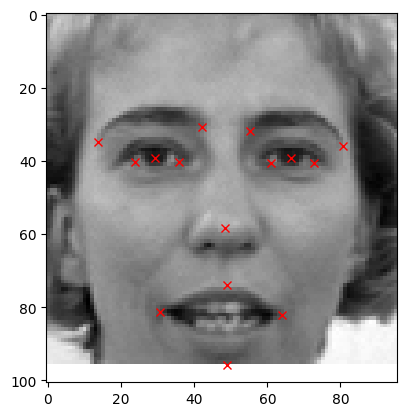

In [ ]:
i = np.random.randint(1,len(train))
plt.imshow(train["Image"][i], cmap="gray")
for j in range(1,31,2):
  plt.plot(train.loc[i][j-1], train.loc[i][j], 'rx')

In [ ]:
train_copy = copy.copy(train)
columns = train_copy.columns[:-1]

In [ ]:
train_copy['Image'] = train_copy['Image'].apply(lambda x: np.flip(x, axis = 1))
for i in range(len(columns)):
  if i%2 == 0:
    train_copy[columns[i]] = train_copy[columns[i]].apply(lambda x: 96. - float(x))
train_augmented =  np.concatenate((train, train_copy))
train_augmented.shape

(4280, 31)

In [ ]:
train_copy = copy.copy(train)
train_copy['Image'] = train_copy['Image'].apply(lambda x:np.clip(np.random.uniform(1.5, 2)* x, 0.0, 255.0))
train_augmented = np.concatenate((train_augmented, train_copy))
train_augmented.shape

(6420, 31)

In [ ]:
train_copy = copy.copy(train)
train_copy['Image'] = train_copy['Image'].apply(lambda x: np.flip(x, axis = 0))
for i in range(len(columns)):
  if i%2 != 0:
    train_copy[columns[i]] = train_copy[columns[i]].apply(lambda x: 96. - float(x))
train_augmented =  np.concatenate((train_augmented, train_copy))
train_augmented.shape

(8560, 31)

/tmp/ipython-input-2019954914.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(train_copy.loc[i][j-1], train_copy.loc[i][j], 'rx')


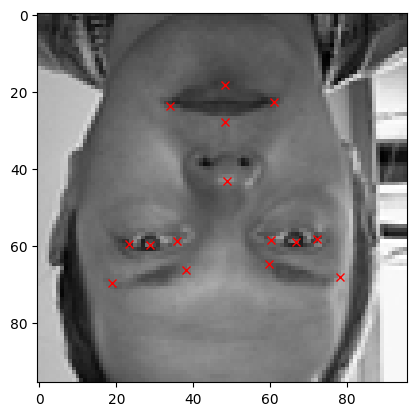

In [ ]:
i = np.random.randint(1,len(train))
plt.imshow(train_copy["Image"][i], cmap="gray")
for j in range(1,31,2):
  plt.plot(train_copy.loc[i][j-1], train_copy.loc[i][j], 'rx')

In [ ]:
img = train_augmented[:,30]
img = img/255.
X = np.empty((len(img), 96, 96, 1))
for i in range(len(img)):
  X[i] = img[i].reshape(96,96,1)
X = np.asarray(X).astype(np.float32)
X.shape

(8560, 96, 96, 1)

6277


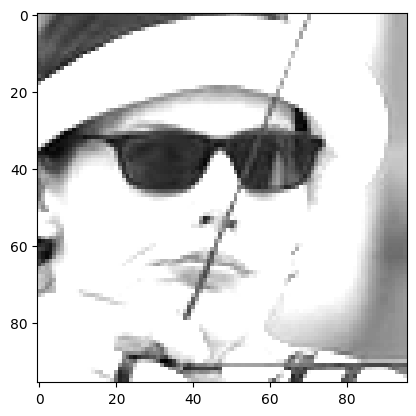

In [ ]:
i = np.random.randint(1,len(X))
print(i)
plt.imshow(X[i], cmap="gray")

In [ ]:
y = train_augmented[:,:30]
y = np.asarray(y).astype(np.float32)
y.shape

(8560, 30)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [ ]:
def res_net(X, filters, stage):
  X_copy = X
  f1 , f2 , f3 = filters

  X = Conv2D(f1, (1,1),strides = (1,1), name ='res_'+str(stage)+'_conv_a', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = MaxPool2D((2,2))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_conv_a')(X)
  X = Activation('relu')(X)

  X = Conv2D(f2, (3,3),strides = (1,1), padding = 'same', name ='res_'+str(stage)+'_conv_b', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_conv_b')(X)
  X = Activation('relu')(X)

  X = Conv2D(f3, (1,1),strides = (1,1), name ='res_'+str(stage)+'_conv_c', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_conv_c')(X)


  X_copy = Conv2D(f3, (1,1),strides = (1,1), name ='res_'+str(stage)+'_conv_copy', kernel_initializer= glorot_uniform(seed = 0))(X_copy)
  X_copy = MaxPool2D((2,2))(X_copy)
  X_copy = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_conv_copy')(X_copy)

  X = layers.Add()([X, X_copy])
  X = Activation('relu')(X)

  X_copy = X

  X = Conv2D(f1, (1,1),strides = (1,1), name ='res_'+str(stage)+'_identity_1_a', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_1_a')(X)
  X = Activation('relu')(X)


  X = Conv2D(f2, (3,3),strides = (1,1), padding = 'same', name ='res_'+str(stage)+'_identity_1_b', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_1_b')(X)
  X = Activation('relu')(X)

  X = Conv2D(f3, (1,1),strides = (1,1), name ='res_'+str(stage)+'_identity_1_c', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_1_c')(X)

  X = layers.Add()([X, X_copy])
  X = Activation('relu')(X)

  X_copy = X

  X = Conv2D(f1, (1,1),strides = (1,1), name ='res_'+str(stage)+'_identity_2_a', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_2_a')(X)
  X = Activation('relu')(X)


  X = Conv2D(f2, (3,3),strides = (1,1), padding = 'same', name ='res_'+str(stage)+'_identity_2_b', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_2_b')(X)
  X = Activation('relu')(X)

  X = Conv2D(f3, (1,1),strides = (1,1), name ='res_'+str(stage)+'_identity_2_c', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_2_c')(X)

  X = layers.Add()([X, X_copy])
  X = Activation('relu')(X)

  return X

In [ ]:
input_shape = (96, 96, 1)

X_input = Input(input_shape)

X = ZeroPadding2D((3,3))(X_input)

X = Conv2D(64, (7,7),strides = (2,2), name ='conv_1', kernel_initializer= glorot_uniform(seed = 0))(X)
X = BatchNormalization(axis =3, name = 'bn_1')(X)
X = Activation('relu')(X)
X = MaxPooling2D((3,3), strides= (2,2))(X)

X = res_net(X, [64,64,256], 2)
X = res_net(X, [128,128,512], 3)

X = AveragePooling2D((2,2), name = 'Averagea_Pooling')(X)

X = Flatten()(X)

X = Dense(4096, activation = 'relu')(X)
X = Dropout(0.2)(X)
X = Dense(2048, activation = 'relu')(X)
X = Dropout(0.1)(X)
X = Dense(30, activation = 'relu')(X)


model_facialKeyPoints = Model( inputs= X_input, outputs = X)
model_facialKeyPoints.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 102, 102,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1 (Conv2D)     │ (None, 48, 48,    │      3,200 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 48, 48,    │        256 │ conv_1[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_29       │ (None, 48, 48,    │          0 │ bn_1[0][0]        │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 23, 23,    │          0 │ activation_29[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_a        │ (None, 23, 23,    │      4,160 │ max_pooling2d_8[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 11, 11,    │          0 │ res_2_conv_a[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_a         │ (None, 11, 11,    │        256 │ max_pooling2d_9[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_30       │ (None, 11, 11,    │          0 │ bn_2_conv_a[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_b        │ (None, 11, 11,    │     36,928 │ activation_30[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_b         │ (None, 11, 11,    │        256 │ res_2_conv_b[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_31       │ (None, 11, 11,    │          0 │ bn_2_conv_b[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_copy     │ (None, 23, 23,    │     16,640 │ max_pooling2d_8[… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_c        │ (None, 11, 11,    │     16,640 │ activation_31[0]… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 11, 11,    │          0 │ res_2_conv_copy[… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_c         │ (None, 11, 11,    │      1,024 │ res_2_conv_c[0][

 Total params: 18,016,286 (68.73 MB)

 Trainable params: 18,007,710 (68.69 MB)

 Non-trainable params: 8,576 (33.50 KB)

In [ ]:
adam = tf.keras.optimizers.Adam(learning_rate = 0.0001, beta_1 = 0.9, beta_2 = 0.999, amsgrad = False)
model_facialKeyPoints.compile(loss = "mean_squared_error", optimizer = adam , metrics = ['accuracy'])

In [ ]:
checkpointer = ModelCheckpoint(filepath = "FacialKeyPoints_weights.keras", verbose = 1, save_best_only = True)
history = model_facialKeyPoints.fit(X_train, y_train, batch_size = 32, epochs = 100, validation_split = 0.05, callbacks=[checkpointer])

Epoch 1/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.3670 - loss: 593.8441
Epoch 1: val_loss improved from inf to 744.39575, saving model to FacialKeyPoints_weights.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 65s 198ms/step - accuracy: 0.3678 - loss: 592.2805 - val_accuracy: 0.3090 - val_loss: 744.3958
Epoch 2/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6753 - loss: 92.7682
Epoch 2: val_loss improved from 744.39575 to 225.12938, saving model to FacialKeyPoints_weights.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.6753 - loss: 92.7241 - val_accuracy: 0.6851 - val_loss: 225.1294
Epoch 3/100
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6618 - loss: 53.9385
Epoch 3: val_loss improved from 225.12938 to 72.61417, saving model to FacialKeyPoints_weights.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.6618 - loss: 53.9319 - val_accuracy: 0.7434 - val_loss: 72.6142
Epoch 4/100
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0

In [ ]:
model_json = model_facialKeyPoints.to_json()
with open("FacialKeyPoints-model.json","w") as json_file:
  json_file.write(model_json)

In [ ]:
result = model_facialKeyPoints.evaluate(X_test, y_test)
print("Accuracy : {}".format(result[1]))

54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8046 - loss: 43.5317
Accuracy : 0.802570104598999


In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

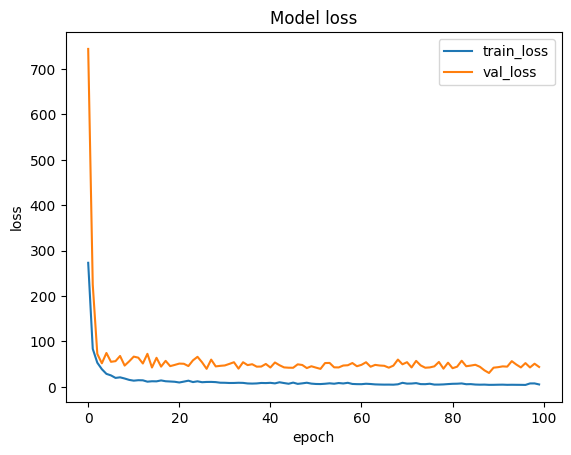

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss','val_loss'], loc = 'upper right')
plt.show()

In [ ]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge

 53% 151M/285M [00:00<00:00, 1.58GB/s]
100% 285M/285M [00:00<00:00, 945MB/s] 


In [ ]:
!unzip challenges-in-representation-learning-facial-expression-recognition-challenge.zip

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: example_submission.csv  
  inflating: fer2013.tar.gz          
  inflating: icml_face_data.csv      
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
train_Exp = pd.read_csv('train.csv')

In [ ]:
train_Exp.head()

,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [ ]:
print(train_Exp["pixels"])

0        70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1        151 150 147 155 148 133 111 140 170 174 182 15...
2        231 212 156 164 174 138 161 173 182 200 106 38...
3        24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4        4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...
                               ...                        
28704    84 85 85 85 85 85 85 85 86 86 86 87 86 86 91 9...
28705    114 112 113 113 111 111 112 113 115 113 114 11...
28706    74 81 87 89 95 100 98 93 105 120 127 133 146 1...
28707    222 227 203 90 86 90 84 77 94 87 99 119 134 14...
28708    195 199 205 206 205 203 206 209 208 210 212 21...
Name: pixels, Length: 28709, dtype: object


In [ ]:
train_Exp["pixels"] = train_Exp["pixels"].apply(lambda x: np.fromstring(x, dtype=float, sep=" ").reshape(48,48))

In [ ]:
print(train_Exp["pixels"][0].shape)
print(train_Exp["pixels"])

(48, 48)
0        [[70.0, 80.0, 82.0, 72.0, 58.0, 58.0, 60.0, 63...
1        [[151.0, 150.0, 147.0, 155.0, 148.0, 133.0, 11...
2        [[231.0, 212.0, 156.0, 164.0, 174.0, 138.0, 16...
3        [[24.0, 32.0, 36.0, 30.0, 32.0, 23.0, 19.0, 20...
4        [[4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
                               ...                        
28704    [[84.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85...
28705    [[114.0, 112.0, 113.0, 113.0, 111.0, 111.0, 11...
28706    [[74.0, 81.0, 87.0, 89.0, 95.0, 100.0, 98.0, 9...
28707    [[222.0, 227.0, 203.0, 90.0, 86.0, 90.0, 84.0,...
28708    [[195.0, 199.0, 205.0, 206.0, 205.0, 203.0, 20...
Name: pixels, Length: 28709, dtype: object


In [ ]:
train_Exp["pixels"] = train_Exp["pixels"].apply(lambda x: cv2.resize(x, dsize=(96, 96), interpolation = cv2.INTER_CUBIC))

In [ ]:
print(train_Exp["pixels"][0].shape)
print(train_Exp["pixels"])

(96, 96)
0        [[69.31692504882812, 73.03865051269531, 79.137...
1        [[151.09434509277344, 150.91392517089844, 150....
2        [[232.8255157470703, 229.81886291503906, 225.5...
3        [[23.061904907226562, 25.509140014648438, 29.4...
4        [[4.7716522216796875, 3.338470458984375, 0.977...
                               ...                        
28704    [[83.77793884277344, 84.14498901367188, 84.749...
28705    [[114.18869018554688, 113.54838562011719, 112....
28706    [[72.80647277832031, 75.02851867675781, 78.615...
28707    [[221.46153259277344, 224.00416564941406, 228....
28708    [[194.77793884277344, 195.93014526367188, 197....
Name: pixels, Length: 28709, dtype: object


In [ ]:
label_to_text = {0:'Anger', 1:'Disgust', 2:'Fear', 3:'Happy', 4: 'Sad',5:'Surprise',6:'Neutral'}

In [ ]:
train_Exp.isnull().sum()

,0
emotion,0
pixels,0


6
Neutral


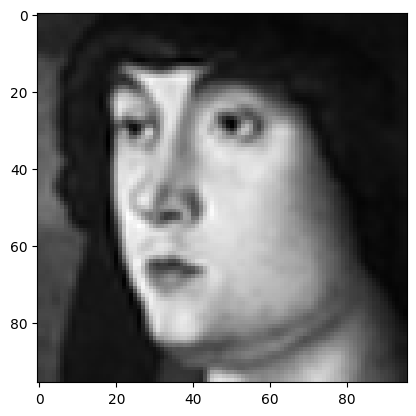

In [ ]:
i = np.random.randint(1,len(train_Exp))
plt.imshow(train_Exp["pixels"][i], cmap="gray")
print(train_Exp["emotion"][i])
print(label_to_text[train_Exp["emotion"][i]])

In [ ]:
train_Exp.emotion.value_counts()

,count
emotion,
3,7215
6,4965
4,4830
2,4097
0,3995
5,3171
1,436


In [ ]:
X = train_Exp["pixels"]
y = to_categorical(train_Exp["emotion"])
X.shape

(28709,)

In [ ]:
X = np.stack(X, axis = 0)
X = X.reshape(X.shape[0], 96, 96, 1)
X.shape

(28709, 96, 96, 1)

In [ ]:
X = X/255.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.24, shuffle = True)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size = 0.5, shuffle = True)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(21818, 96, 96, 1)
(3445, 96, 96, 1)
(3446, 96, 96, 1)


In [ ]:
train_datagen = ImageDataGenerator(
rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    shear_range = 0.1,
    zoom_range = 0.1,
    horizontal_flip = True,
    fill_mode = "nearest")

In [ ]:
input_shape = (96, 96, 1)

X_input = Input(input_shape)

X = ZeroPadding2D((3, 3))(X_input)

X = Conv2D(64, (7, 7), strides=(2, 2), name='conv_1', kernel_initializer=glorot_uniform(seed=0))(X)
X = BatchNormalization(axis=3, name='bn_1')(X)
X = Activation('relu')(X)
X = MaxPooling2D((3, 3), strides=(2, 2))(X)

X = res_net(X, [64, 64, 256], 2)
X = res_net(X, [128, 128, 512], 3)
X = res_net(X, [256, 256, 1024], 4)

X = AveragePooling2D((2, 2), name='Averagea_Pooling')(X)

X = Flatten()(X)
X = Dense(512, activation='relu')(X)
X = Dropout(0.2)(X)
X = Dense(7,activation='softmax',name = 'Dense_final', kernel_initializer= glorot_uniform(seed=0))(X)

model_emotion = Model(inputs=X_input, outputs=X)
model_emotion.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 102, 102,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1 (Conv2D)     │ (None, 48, 48,    │      3,200 │ zero_padding2d_1… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 48, 48,    │        256 │ conv_1[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 48,    │          0 │ bn_1[0][0]        │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 23, 23,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_a        │ (None, 23, 23,    │      4,160 │ max_pooling2d_1[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 11, 11,    │          0 │ res_2_conv_a[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_a         │ (None, 11, 11,    │        256 │ max_pooling2d_2[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 11, 11,    │          0 │ bn_2_conv_a[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_b        │ (None, 11, 11,    │     36,928 │ activation_2[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_b         │ (None, 11, 11,    │        256 │ res_2_conv_b[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 11, 11,    │          0 │ bn_2_conv_b[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_copy     │ (None, 23, 23,    │     16,640 │ max_pooling2d_1[… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_c        │ (None, 11, 11,    │     16,640 │ activation_3[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 11, 11,    │          0 │ res_2_conv_copy[… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_c         │ (None, 11, 11,    │      1,024 │ res_2_conv_c[0][

 Total params: 5,463,559 (20.84 MB)

 Trainable params: 5,443,719 (20.77 MB)

 Non-trainable params: 19,840 (77.50 KB)

In [ ]:
model_emotion.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
earlystopping = EarlyStopping(monitor = 'val_loss', mode = 'min', verbose = 1, patience = 20)
checkpointer = ModelCheckpoint(filepath = "emtion_weights.keras", verbose = 1, save_best_only=True)

In [ ]:
history = model_emotion.fit(train_datagen.flow(X_train, y_train, batch_size=32), validation_data=(X_val, y_val), steps_per_epoch=len(X_train) // 32, epochs= 50, callbacks=[checkpointer, earlystopping])

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


680/681 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.2409 - loss: 2.1887
Epoch 1: val_loss improved from inf to 1.66619, saving model to emtion_weights.keras
681/681 ━━━━━━━━━━━━━━━━━━━━ 90s 79ms/step - accuracy: 0.2410 - loss: 2.1877 - val_accuracy: 0.3260 - val_loss: 1.6662
Epoch 2/50
  1/681 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.3750 - loss: 1.6670

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss did not improve from 1.66619
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3750 - loss: 1.6670 - val_accuracy: 0.3100 - val_loss: 1.7143
Epoch 3/50
680/681 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3700 - loss: 1.6067
Epoch 3: val_loss did not improve from 1.66619
681/681 ━━━━━━━━━━━━━━━━━━━━ 28s 42ms/step - accuracy: 0.3701 - loss: 1.6065 - val_accuracy: 0.2560 - val_loss: 1.7406
Epoch 4/50
  1/681 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.2500 - loss: 1.5809
Epoch 4: val_loss did not improve from 1.66619
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2500 - loss: 1.5809 - val_accuracy: 0.2630 - val_loss: 1.7221
Epoch 5/50
680/681 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4204 - loss: 1.4813
Epoch 5: val_loss improved from 1.66619 to 1.49385, saving model to emtion_weights.keras
681/681 ━━━━━━━━━━━━━━━━━━━━ 30s 45ms/step - accuracy: 0.4204 - loss: 1.4812 - val_accuracy: 0.4148 - val_loss: 1.4938
Epoch 6/50
  1/681 ━━━━━━━━━━━━━━━━

In [ ]:
print("Accuracy : {}".format(model_emotion.evaluate(X_test, y_test)[1]))

108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5496 - loss: 1.1873
Accuracy : 0.5435287356376648


In [ ]:
def pred(X):
  pred = model_facialKeyPoints.predict(X)
  em_pred = np.expand_dims(np.argmax(model_emotion.predict(X), axis=-1),axis=1)
  pred = pd.DataFrame(pred)
  pred["emotion"]= em_pred
  return pred


In [ ]:
pred = pred(X_test)
print(pred)

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
              0          1          2          3          4          5  \
0     68.149963  60.320541  28.216690  54.933826  58.994370  57.761711   
1     32.404579  37.487972  66.996475  37.541721  38.294525  38.410229   
2     31.094923  39.519077  65.202133  37.345722  36.892532  39.965214   
3     65.898605  41.027508  30.121378  40.236881  60.178909  41.293652   
4     67.918373  37.238411  29.719637  35.920238  58.927441  38.624866   
...         ...        ...        ...        ...        ...        ...   
1707  29.933844  34.057400  67.697182  36.798023  35.575233  35.034485   
1708  30.659985  38.403881  66.077690  37.365688  37.959328  39.007050   
1709  67.902496  61.130451  30.209570  61.867306  61.801750  60.622089   
1710  66.810852  59.706402  31.093588  60.939083  59.331696  58.876488   
1711  31.067713  38.454937  67.003746  37.979633  36.667614  38.912090   

              6          7      

Neutral


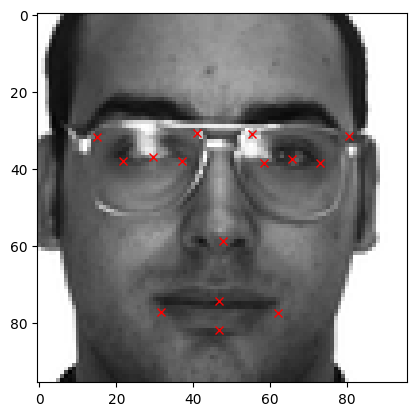

In [ ]:
i = np.random.randint(1,len(X_test))
plt.imshow(X_test[i], cmap="gray")
print(label_to_text[pred["emotion"][i]])
for j in range(1,31,2):
  plt.plot(pred.loc[i][j-1], pred.loc[i][j], 'rx')